<a href="https://colab.research.google.com/github/simondiange/simondiange/blob/main/Breast_cancer_prediction(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HND DEFENCE SUPERVISED BY ENGR BADU ZAMANI

Analyze breast cancer data by loading and preprocessing the dataset, building and training a Convolutional Neural Network (CNN) model, and evaluating its performance using a confusion matrix.

## Load and Preprocess Data


Load the breast cancer dataset, perform necessary preprocessing steps such as resizing images (if applicable), normalization, and split the data into training and testing sets.



The first step is to import the necessary libraries as specified in the instructions to prepare for data loading and preprocessing. I will import `tensorflow`, `numpy`, `matplotlib.pyplot`, and `sklearn.model_selection`.



In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
import pandas as pd

print("Libraries imported successfully.")

Libraries imported successfully.



Now that the libraries are imported, the next step is to load the breast cancer dataset using `load_breast_cancer` from `sklearn.datasets`.



In [ ]:
data = load_breast_cancer()
X = data.data  # Features
y = data.target # Target (labels)

print("Breast cancer dataset loaded successfully.")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Breast cancer dataset loaded successfully.
Features shape: (569, 30)
Target shape: (569,)



Now that the data is loaded, the next step is to explore the dataset's structure by displaying the feature names, a brief description, and the first few rows of the features (`X`) to understand its contents and data types.



In [ ]:
print("Feature names:", data.feature_names)
print("\nDataset Description:", data.DESCR)

# Display the first 5 rows of features
print("\nFirst 5 rows of features (X):\n", X[:5])
print("\nData types of features (X):", X.dtype)

# Display the first 5 rows of target labels
print("\nFirst 5 rows of target (y):\n", y[:5])
print("\nData types of target (y):", y.dtype)

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Dataset Description: .. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - p


Since the dataset is tabular, has no missing values, and all features are numerical, the next step is to normalize the numerical features to ensure they contribute equally to the model training. I will use `StandardScaler` for this.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the features and transform them
X_scaled = scaler.fit_transform(X)

print("Features normalized successfully.")
print("First 5 rows of scaled features (X_scaled):\n", X_scaled[:5])
print("Data types of scaled features (X_scaled):", X_scaled.dtype)

Features normalized successfully.
First 5 rows of scaled features (X_scaled):
 [[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.3044421


Now that the features have been normalized, the next step is to split the dataset into training and testing sets. This is crucial for evaluating the model's performance on unseen data. I will use `train_test_split` from `sklearn.model_selection`, allocating 20% of the data for testing and ensuring stratification to maintain the class distribution.



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


## Build CNN Model


Construct the Convolutional Neural Network (CNN) architecture. This will involve defining layers suitable for image classification. Include comments and headings to explain each part of the model.



The first instruction requires reshaping the training and testing data to include a channel dimension, which is necessary before defining the CNN architecture with `Conv1D` layers. I will reshape `X_train` and `X_test` from `(num_samples, 30)` to `(num_samples, 30, 1)` and then print their new shapes to verify this change.



In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"New X_train shape: {X_train.shape}")
print(f"New X_test shape: {X_test.shape}")

New X_train shape: (455, 30, 1)
New X_test shape: (114, 30, 1)



Now that the data is reshaped, the next step is to import the necessary `tensorflow.keras` modules, including `Sequential` for model definition and various layers such as `Conv1D`, `MaxPooling1D`, `Flatten`, and `Dense`, as specified in instruction



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

print("Keras layers and Sequential model imported successfully.")

Keras layers and Sequential model imported successfully.



Following the import of Keras modules, the next logical step is to instantiate a `Sequential` model. This will serve as the container for adding the CNN layers.



In [ ]:
model = Sequential()

print("Sequential model instantiated.")

Sequential model instantiated.



Now that the `Sequential` model is instantiated, the next step is to add the first `Conv1D` layer. This layer will have 32 filters, a kernel size of 3, 'relu' activation, and an `input_shape` of `(30, 1)` to match our reshaped data.



In [ ]:
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))

print("First Conv1D layer added.")

First Conv1D layer added.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Following the addition of the first `Conv1D` layer, the next step is to add a `MaxPooling1D` layer with a pool size of 2. This layer will reduce the dimensionality of the feature maps, helping to control overfitting and reduce computational complexity.



In [ ]:
model.add(MaxPooling1D(pool_size=2))

print("MaxPooling1D layer added.")

MaxPooling1D layer added.



Now that the first `MaxPooling1D` layer has been added, the next step is to add another `Conv1D` layer with 64 filters, a kernel size of 3, and 'relu' activation. This will extract more complex features from the data.



In [ ]:
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))

print("Second Conv1D layer added.")

Second Conv1D layer added.



Following the second `Conv1D` layer, the next step is to add another `MaxPooling1D` layer with a pool size of 2. This further reduces dimensionality and helps in feature learning.



In [ ]:
model.add(MaxPooling1D(pool_size=2))

print("Second MaxPooling1D layer added.")

Second MaxPooling1D layer added.



Now that the second `MaxPooling1D` layer has been added, the next step is to add a `Flatten` layer as specified in instruction. This layer will convert the 3D output of the convolutional layers into a 1D vector, preparing it for the dense layers.



In [ ]:
model.add(Flatten())

print("Flatten layer added.")

Flatten layer added.



Now that the `Flatten` layer has been added, the next step is to add a `Dense` hidden layer with 100 units and 'relu' activation. This layer will process the flattened features before the final output layer.



In [ ]:
model.add(Dense(100, activation='relu'))

print("Dense hidden layer added.")

Dense hidden layer added.



Now that the hidden dense layer has been added, the next step is to add the output `Dense` layer with 1 unit and 'sigmoid' activation for binary classification, as specified in instruction



In [ ]:
model.add(Dense(1, activation='sigmoid'))

print("Output Dense layer added.")

Output Dense layer added.



Now that all the layers have been added to the CNN model, the final step in constructing the model architecture, is to print `model.summary()` to display its complete architecture and parameter count.



In [ ]:
model.summary()

print("Model summary displayed.")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 28, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 12, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        38,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,937 (175.54 KB)

 Trainable params: 44,937 (175.54 KB)

 Non-trainable params: 0 (0.00 B)

Model summary displayed.


## Train CNN Model


Compile the CNN model with an appropriate optimizer and loss function, then train it using the preprocessed training data. Ensure clear headings are used.



The next step is to compile the model using the `.compile()` method with the specified optimizer, loss function, and metrics.



In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Model compiled successfully.")

Model compiled successfully.



Now that the model is compiled, the next step is to train it using the `.fit()` method with the specified training and validation data, epochs, and batch size. The training history will be stored in the `history` variable.



In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

print("Model training complete.")

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8571 - loss: 0.4390 - val_accuracy: 0.9123 - val_loss: 0.2545
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9275 - loss: 0.1863 - val_accuracy: 0.9123 - val_loss: 0.1952
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9516 - loss: 0.1372 - val_accuracy: 0.9561 - val_loss: 0.1081
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9648 - loss: 0.1132 - val_accuracy: 0.9474 - val_loss: 0.1068
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9604 - loss: 0.0911 - val_accuracy: 0.9561 - val_loss: 0.1135
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9758 - loss: 0.0746 - val_accuracy: 0.9474 - val_loss: 0.1156
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9802 - loss: 0.0635 - val_accuracy: 0.9561 - val_loss: 0.1078
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9802 - loss: 0.0585 - val_accuracy: 0.9561 - val_loss

## Evaluate Model using Confusion Matrix


Evaluate the trained model's performance on the test set. Generate and display a confusion matrix to clearly show the true positives, true negatives, false positives, and false negatives. Provide comments to explain the output.


**Reasoning**:
The first step in evaluating the model is to import the necessary metrics from `sklearn.metrics`, specifically `confusion_matrix` and `classification_report`, as specified in instruction #1 of the subtask.



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("Scikit-learn metrics imported successfully.")

Scikit-learn metrics imported successfully.



Now that the necessary evaluation metrics are imported, the next step is to make predictions on the `X_test` data using the trained `model`. These predictions will be stored in `y_pred`.



In [ ]:
y_pred = model.predict(X_test)

print("Predictions on X_test generated.")
print(f"y_pred shape: {y_pred.shape}")

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predictions on X_test generated.
y_pred shape: (114, 1)



Now that predictions have been generated, the next step is to convert the predicted probabilities from `y_pred` into binary class labels (0 or 1) using a threshold of 0.5. These binary predictions will be stored in `y_pred_binary`.



In [ ]:
y_pred_binary = (y_pred > 0.5).astype(int)

print("Predicted probabilities converted to binary labels.")
print(f"First 5 binary predictions: {y_pred_binary[:5].flatten()}")

Predicted probabilities converted to binary labels.
First 5 binary predictions: [0 1 0 0 0]



Now that binary predictions are available, the next step is to generate the confusion matrix using `y_test` and `y_pred_binary`. This will provide a foundational view of the model's classification performance.



In [ ]:
cm = confusion_matrix(y_test, y_pred_binary)

print("Confusion matrix generated.")

Confusion matrix generated.



Now that the confusion matrix (`cm`) has been generated, the next step is to print it. This will display the true positives, true negatives, false positives, and false negatives.



In [ ]:
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[39  3]
 [ 2 70]]


The confusion matrix visualized using the following code:

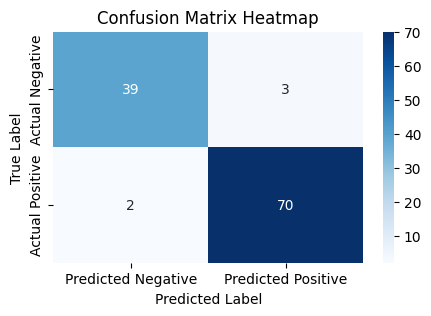

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Now that the confusion matrix has been printed, the final step for evaluating the model is to print a classification report. This will provide a comprehensive view of precision, recall, and F1-score.



In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary))


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

